In [ ]:
import numpy as np
import scipy.fft as fft
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from functools import partial
import pandas as pd

"""
read data from raw filamentJ plugin output.
main problem is that each frame does not have an equal number of points, but this is fixed later.
"""
def read_tracking_data(file_path):

    frames = {}
    with open(file_path, 'r') as f:
        for line in f:
            if len(line.strip().split('\t')) == 5:
                parts = line.strip().split('\t')
                frame_id = int(parts[0])
                point_id = int(parts[1])
                x = float(parts[2])
                y = float(parts[3])

                if frame_id not in frames:
                    frames[frame_id] = []
                frames[frame_id].append((x, y))

    #delete frames with less than 7 coordinates, spline cannot fit these
    frames = {frame_id:frame for frame_id,frame in frames.items() if len(frame) > 6}

    return frames

"""
load in tracking data from other tracking .txt format (neither the current imageJ plugin nor my python code)
this data was probably preprocessed, and usually has names like txt1_27beads.txt
"""
def parse_tracking_data_old(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    coordinates = []

    for i in range(0, len(lines), 2):
        x_coords = list(map(float, lines[i].split()[1:]))
        y_coords = list(map(float, lines[i + 1].split()[1:]))
        coords = np.array(list(zip(x_coords, y_coords)))
        coordinates.append(coords)

    return np.array(coordinates)

"""
find distance array, that is, convert (x,y) -> L2 distance from mean
"""
def distances(coords):
    frames = coords.shape[0]

    #this is a (Nx2) matrix, N = number of points used to track, representing mean positions
    means = np.mean(coords,axis=0)

    #distance array
    dists = coords-np.array(np.array(frames*[means]))
    dists = np.linalg.norm(coords, 2, axis=2)

    return dists

"""
Calculate FFT, then F(q), then omega(q) of distances.
"""
def distances_to_phonons(dists, k_b = 1.38e-23, T = 298, m = 1e-10, num_points = 1):
    fft_dists = fft.fft(dists,axis=1)
    variances = np.var(fft_dists,axis=0)
    F = 2*k_b*T/variances
    omegas = np.sqrt(F/m)

    #convert from interval [0,2pi] to [-pi,pi]
    omegas = np.concatenate((np.array_split(omegas,2)[1],np.array_split(omegas,2)[0]))

    return omegas

"""
takes in dict of frames -> coordinates per frame, with the number of points perhaps varying across per frame.
fits splines, then returns np.array with equally spaced, constant number of points.
used for raw filamentJ data.
"""
def fit_spline_equally_spaced(coordinates, num_points=50):

    x = np.array([coord[0] for coord in coordinates])
    y = np.array([coord[1] for coord in coordinates])

    # Fit the parametric spline
    tck, u = splprep([x, y], s=0)

    # Evaluate the first derivative to approximate arc length
    x_der, y_der = splev(u, tck, der=1)
    ds = np.sqrt(x_der**2 + y_der**2)
    s = np.cumsum(ds)
    s = np.insert(s, 0, 0)  # Insert the starting point for cumulative sum
    s = np.delete(s,0)

    s_uniform = np.linspace(0, s[-1], num_points+2)
    s_uniform = np.delete(s_uniform,(0,1))

    u_uniform = np.interp(s_uniform, s, u)
    x_new, y_new = splev(u_uniform, tck)

    coordinates_array = np.transpose(np.array([x_new, y_new]))
    return coordinates_array


"""
Main function for all of this.
raw_coordinates just says if the data being loaded in is filamentJ raw output, true by default.
file_path is the full path to the file. If on windows, makesure all backslashes are replaced by forward slashes.
"""
def get_phonon_spectrum(file_path, num_points, raw_coordinates = True, tubule_mass = None, conversion_factor = None):

    #some mass calculations, courtesy of emil
    #need to do this microtubule by microtubule, I haven't really examined this yet so I'm just taking his word on it
    if conversion_factor is None:
        digital_to_meters_conversion = 1
    else:
        digital_to_meters_conversion = conversion_factor*1e-6

    dimer_mass = None
    if tubule_mass is not None:
        dimer_mass = tubule_mass/num_points

    if raw_coordinates is True:
        #raw filamentJ data

        #load in data
        frames = read_tracking_data(file_path)
        frames = list(frames.values())
        
        def curve_length(points):

            if len(points) < 2:
                return 0.0

            length = 0.0
            for i in range(1, len(points)):
                dx = points[i][0] - points[i - 1][0]
                dy = points[i][1] - points[i - 1][1]
                length += np.sqrt(dx**2 + dy**2)

            return length

        if tubule_mass is None:
            dimer_MW = 110
            dimer_mass = dimer_MW/(6.022e23)
            Lc = np.mean(np.array([curve_length(frame) for frame in frames]))
            actual_mass = Lc * 0.055 * 1625 * dimer_mass
            dimer_mass = actual_mass/num_points

        #partially evaluate function to tell it number of points
        fit_spline_equally_spaced_partial = partial(fit_spline_equally_spaced,num_points=num_points)

        #spline-fit and then segment into needed number of segements
        equally_spaced_data = list(map(fit_spline_equally_spaced_partial,frames))
        equally_spaced_data = np.array(equally_spaced_data)

        #calculate distances, then omega(q)
        dists = digital_to_meters_conversion*distances(equally_spaced_data)
        omegas = distances_to_phonons(dists,m=dimer_mass)

    else:

        #load in data
        frames = parse_tracking_data_old(file_path)

        #calculate distances, then omega(q)
        dists = distances(frames)
        omegas = distances_to_phonons(dists)

    return omegas
import scipy.stats as stats


"""
given the set of some frequencies from -pi to pi, find the right derivative at k=0 of the band spectrum.
WARNING: assumes band has a minimum at 0.
"""
def get_velocity(freqs,h_param = 0.02):

    freqs = freqs

    lower = len(freqs)/2
    if len(freqs) < 1000:
        lower = np.argmin(freqs)
        h = 0.15
        print("higher number of points reccomended!")

    upper = lower + h_param*(len(freqs)/2)
    relevant_seg = freqs[int(lower):int(upper)]

    velocity = 0
    if len(relevant_seg) > 4:
        res = stats.linregress(np.linspace(0,np.pi*h_param,num = len(relevant_seg)),relevant_seg)
        velocity = res.slope

    return velocity

"""
Does everything: plots 26,50,100 points, calculates velocity, plots that as well
"""
def plot_phonon_spectrum(file_path, raw_coordinates = True, tubule_mass = None, resolutions = None, excel_filename = None, excel_filename1 = None, conversion_factor_a = None):
    conversion_factor = 1
    if resolutions is not None:
        resolution_microns = resolutions[0]
        resolution_pixels = resolutions[1]
        conversion_factor = resolution_microns[0]/resolution_pixels[0]
    if conversion_factor_a is not None:
        conversion_factor = conversion_factor_a
    lower, upper = -np.pi, np.pi

    omegas1 = get_phonon_spectrum(file_path=file_path_1, num_points=26, tubule_mass = tubule_mass, conversion_factor = conversion_factor)
    plt.scatter(np.linspace(lower, upper,num=len(omegas1)),omegas1, s=2, label = '26')
    omegas2 = get_phonon_spectrum(file_path=file_path_1, num_points=50, tubule_mass = tubule_mass, conversion_factor = conversion_factor)
    plt.scatter(np.linspace(lower, upper,num=len(omegas2)),omegas2, s=2, label = '50')
    omegas3 = get_phonon_spectrum(file_path=file_path_1, num_points=100, tubule_mass = tubule_mass, conversion_factor = conversion_factor)
    plt.scatter(np.linspace(lower, upper,num=len(omegas3)),omegas3, s=2, label = '100')

    #set tickmarks
    plt.rcParams['axes.xmargin'] = 0
    plt.xticks(np.linspace(lower, upper,num=9,endpoint=True),['-π','','-π/2','','0','','π/2','','π'])

    #plot!
    plt.title(r'Phonon spectrum $\omega(q)$, with $q \in [-\pi,\pi]$')
    plt.xlabel('q (1/micron)')
    plt.ylabel('$\omega (Hz)$')
    plt.legend(loc=3)
    plt.show()

    if excel_filename is not None and excel_filename1 is not None:
        # Export omegas3 and q values to an Excel file
        q_values = np.linspace(lower, upper, num=len(omegas3))

        # Create a DataFrame from the data
        data = {'q': q_values, 'omegas3': omegas3}
        df = pd.DataFrame(data)
        df.to_excel(excel_filename1, index=False)

        print(f'Data exported to {excel_filename}')

    plt.clf()

    lower,upper = 0,np.pi/3

    #get velocity and plot line
    omegas = get_phonon_spectrum(file_path=file_path_1, num_points=10000, tubule_mass = tubule_mass, conversion_factor = conversion_factor)
    velocity = get_velocity(omegas)
    plt.scatter(np.linspace(-np.pi,np.pi,num=len(omegas)),omegas,s=2)
    print(f'velocity = {velocity}')

    #set tickmarks
    plt.xlim(lower,upper)
    plt.rcParams['axes.xmargin'] = 0
    plt.xticks(np.linspace(lower, upper,num=3,endpoint=True),['0','','π/3'])

    #plot!
    plt.title(r'Phonon spectrum with speed')
    plt.xlabel('q (1/micron)')
    plt.ylabel('$\omega (Hz)$')

    plt.plot([0,upper/2],[0,velocity*upper/2],color='red',label='velocity')
    plt.legend(['Phonon spectrum','Velocity tangent to spectrum'])
    plt.show()



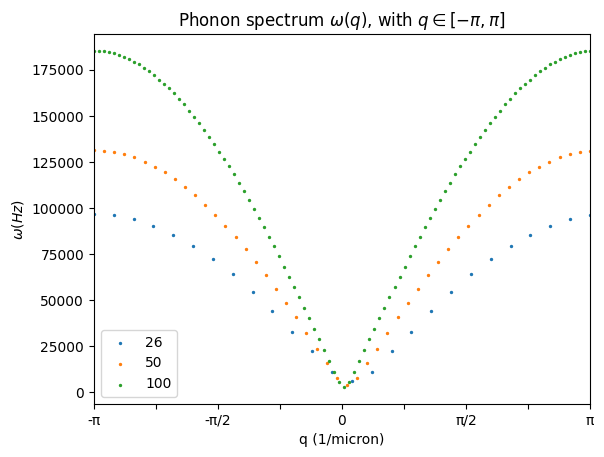

velocity = 904206.241941042


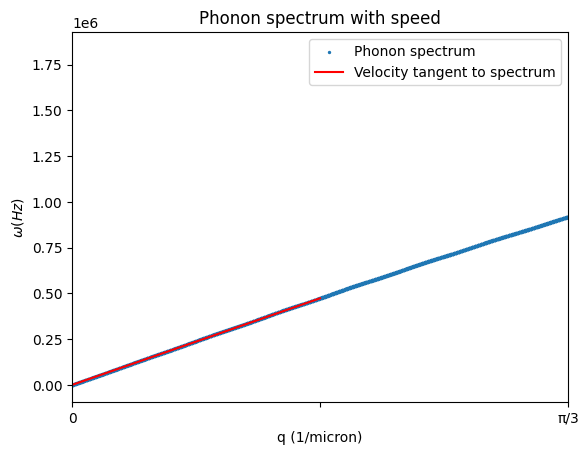

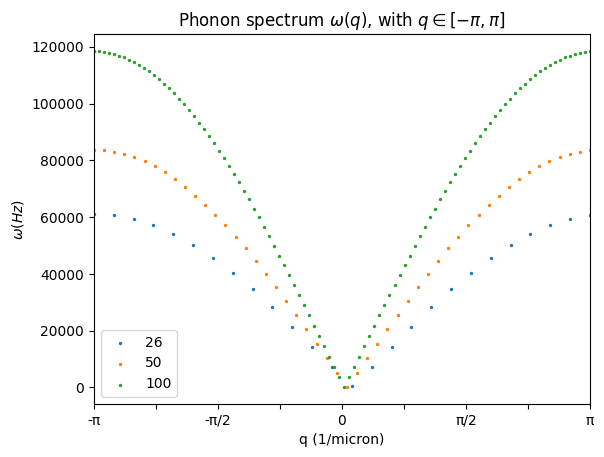

velocity = 587967.6581664461


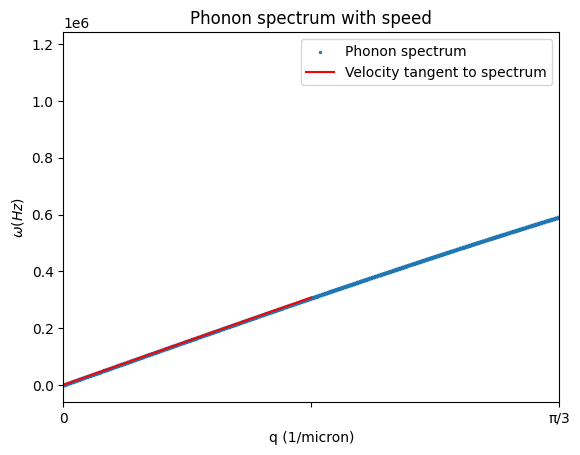

In [7]:
#everything that one needs to input is here, running this cell will plot everything for the content file

#enter file path here!
file_path_1 = '/home/yuming/Documents/mt_data/mt_data/Python_Snake_Files/Standard/5_31/MT2/MT2.txt'

#enter total microtubule mass and conversion here when ready, it will still work (as in produce an output)
#when dimer is None, but to get actual results please enter the actual mass if you're not testing.
tubule_mass = None
conversion_factor = 0.55

#excel spreadsheet stuff here, if it is set to None then the code will still work

# Specify the path where you want to save the file
excel_filename = None
excel_filename1 = None

#plot everything
plot_phonon_spectrum(file_path_1, raw_coordinates = True, tubule_mass = tubule_mass, resolutions = None,
                     excel_filename = excel_filename, excel_filename1 = excel_filename1, conversion_factor_a = conversion_factor)

#everything that one needs to input is here, running this cell will plot everything for the content file

#enter file path here!
file_path_1 = '/home/yuming/Documents/mt_data/mt_data/Python_Snake_Files/HeLa/6_14/MT1/MT1.txt'

#enter total microtubule mass and conversion here when ready, it will still work (as in produce an output)
#when dimer is None, but to get actual results please enter the actual mass if you're not testing.
tubule_mass = None
conversion_factor = 0.55

#excel spreadsheet stuff here, if it is set to None then the code will still work

# Specify the path where you want to save the file
excel_filename = None
excel_filename1 = None

#plot everything
plot_phonon_spectrum(file_path_1, raw_coordinates = True, tubule_mass = tubule_mass, resolutions = None,
                     excel_filename = excel_filename, excel_filename1 = excel_filename1, conversion_factor_a = conversion_factor)

ModuleNotFoundError: No module named 'fresh_implementation'